# When does classical ML become worth moving to a GPU?

This output-complete notebook analyzes the confirmed estimator, inference, and end-to-end placement matrices. It reads published condition summaries only; a GPU is not required to reproduce these tables and charts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid', context='notebook')
RESULTS = Path('results')
estimators = pd.read_csv(RESULTS / 'published_estimator_results.csv')
inference = pd.read_csv(RESULTS / 'published_inference_results.csv')
pipelines = pd.read_csv(RESULTS / 'published_pipeline_results.csv')
estimators.shape, inference.shape, pipelines.shape

((104, 25), (293, 10), (30, 31))

## Publication controls

Every row below is a median across three fresh processes. The private runner generated these summaries only after algorithm-specific quality checks and `cuml.accel` GPU-dispatch checks passed.

In [2]:
assert estimators['replications'].eq(3).all()
assert pipelines['replications'].eq(3).all()
assert set(pipelines['mode']) == {'cpu', 'accel', 'gpu_resident', 'cpu_to_gpu', 'ping_pong'}
quality = (estimators.groupby('algorithm', as_index=False)
           .agg(min_quality_gap=('quality_gap_vs_cpu', 'min'),
                max_quality_gap=('quality_gap_vs_cpu', 'max'),
                conditions=('dataset_id', 'size')))
quality

,algorithm,min_quality_gap,max_quality_gap,conditions
0,hdbscan,-0.000591,0.000000e+00,9
1,kmeans,-0.111936,2.257604e-01,18
2,logistic_regression,-0.000009,5.630955e-07,21
3,pca,-0.000081,4.112720e-06,21
4,random_forest,-0.000242,9.529016e-05,12
5,umap,-0.000875,6.539157e-04,9
6,xgboost,-0.000231,1.184950e-04,14


## A fast fit is not automatically a fast lifecycle

The x-axis times only `fit()`. The y-axis also charges warm-cache loading and the explicit upload used by native GPU estimators. Points below the diagonal surrendered part of their kernel win before inference began.

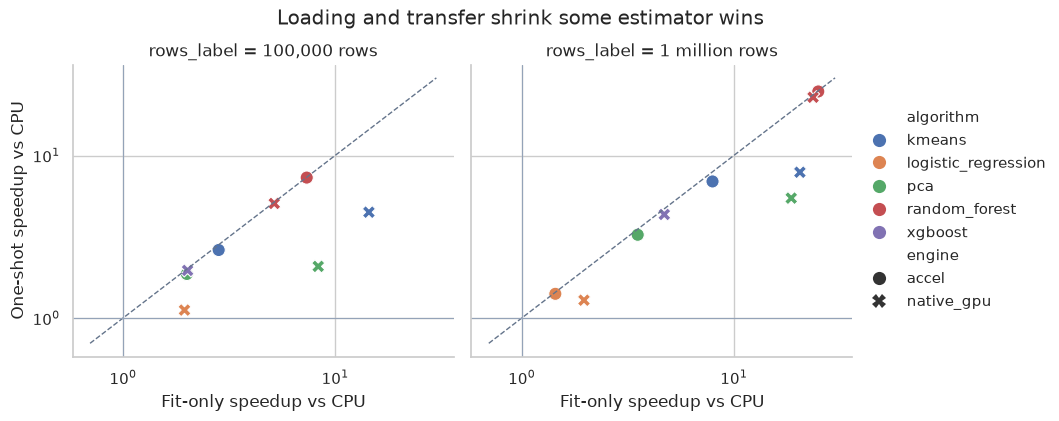

In [3]:
focus = estimators[
    estimators['dataset_id'].str.contains(r'r(?:100000|1000000)-f64')
    & estimators['algorithm'].isin(['pca','kmeans','logistic_regression','random_forest','xgboost'])
    & estimators['engine'].ne('cpu')
].copy()
focus['rows_label'] = focus['rows'].map({100_000:'100,000 rows',1_000_000:'1 million rows'})
chart = sns.relplot(data=focus, x='fit_speedup_vs_cpu', y='one_shot_speedup_vs_cpu',
                    hue='algorithm', style='engine', col='rows_label', s=90, height=4, aspect=1.1,
                    facet_kws={'sharex': True, 'sharey': True})
for axis in chart.axes.flat:
    low, high = 0.7, max(focus['fit_speedup_vs_cpu'].max(), focus['one_shot_speedup_vs_cpu'].max()) * 1.2
    axis.plot([low, high], [low, high], '--', color='#64748b', linewidth=1)
    axis.axhline(1, color='#94a3b8', linewidth=0.8)
    axis.axvline(1, color='#94a3b8', linewidth=0.8)
    axis.set(xscale='log', yscale='log')
chart.set_axis_labels('Fit-only speedup vs CPU', 'One-shot speedup vs CPU')
chart.figure.suptitle('Loading and transfer shrink some estimator wins', y=1.04)
plt.show()

The table keeps both numbers. That makes the result usable for a repeatedly fitted, already-resident workload and for a one-shot host-resident workload without conflating them.

In [4]:
row_scale = estimators[
    estimators['dataset_id'].str.contains(r'r(?:20000|100000|1000000|5000000)-f64')
    & estimators['engine'].ne('cpu')
].copy()
row_scale.pivot_table(index=['rows','algorithm'], columns='engine',
                      values='one_shot_speedup_vs_cpu').round(2)

engine                       accel  native_gpu
rows    algorithm                             
20000   kmeans                2.17        2.57
        logistic_regression   0.52        0.52
        pca                   1.43        1.15
        random_forest         1.90        1.15
        xgboost                NaN        1.11
100000  kmeans                2.62        4.48
        logistic_regression   1.86        1.12
        pca                   1.87        2.08
        random_forest         7.32        5.07
        xgboost                NaN        1.97
1000000 kmeans                6.93        7.89
        logistic_regression   1.41        1.29
        pca                   3.26        5.47
        random_forest        24.78       22.82
        xgboost                NaN        4.34
5000000 kmeans                6.58        8.05
        logistic_regression   5.05        3.40
        pca                   3.67        7.36
        xgboost                NaN        5.44

## Placement sets the end-to-end boundary

Each trial includes load, scaling, nonlinear features, PCA, Logistic Regression, probability inference, and host materialization. The four accelerated paths differ only in where those stages execute and how often data crosses the boundary.

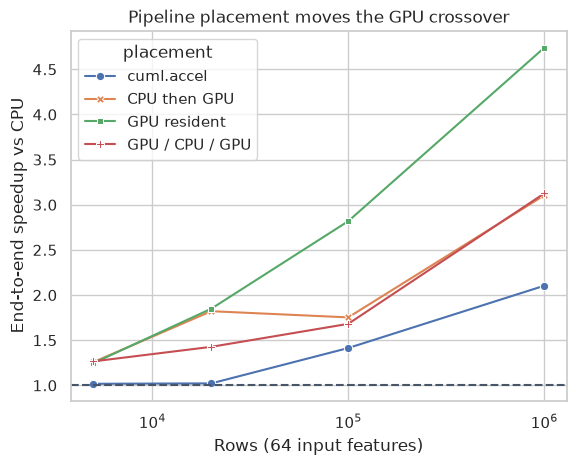

In [5]:
row_pipelines = pipelines[
    pipelines['dataset_id'].str.contains(r'r(?:5000|20000|100000|1000000)-f64')
    & pipelines['mode'].ne('cpu')
].copy()
row_pipelines['placement'] = row_pipelines['mode'].map({
    'accel':'cuml.accel','gpu_resident':'GPU resident',
    'cpu_to_gpu':'CPU then GPU','ping_pong':'GPU / CPU / GPU'})
sns.lineplot(data=row_pipelines, x='rows', y='speedup_vs_cpu', hue='placement',
             style='placement', markers=True, dashes=False)
plt.axhline(1, color='#475569', linestyle='--')
plt.xscale('log')
plt.xlabel('Rows (64 input features)')
plt.ylabel('End-to-end speedup vs CPU')
plt.title('Pipeline placement moves the GPU crossover')
plt.show()

## Width, transfers, and CPU islands

The transfer count is explicit for native and hybrid paths. `cuml.accel` manages conversion internally, so its end-to-end time—not a zero in the explicit-transfer columns—is the meaningful comparison.

In [6]:
view = pipelines[[
    'rows','features','mode','total_seconds','speedup_vs_cpu','transfer_count',
    'host_to_device_gib','device_to_host_gib','roc_auc'
]].copy()
view.sort_values(['rows','features','mode']).round(4)

,rows,features,mode,total_seconds,speedup_vs_cpu,transfer_count,host_to_device_gib,device_to_host_gib,roc_auc
25,5000,64,accel,0.0151,1.0177,0.0,0.0000,0.0000,0.9544
26,5000,64,cpu,0.0154,1.0000,0.0,0.0000,0.0000,0.9544
27,5000,64,cpu_to_gpu,0.0122,1.2573,2.0,0.0014,0.0000,0.9544
28,5000,64,gpu_resident,0.0124,1.2460,2.0,0.0012,0.0000,0.9544
29,5000,64,ping_pong,0.0122,1.2657,4.0,0.0026,0.0012,0.9544
20,20000,64,accel,0.0257,1.0220,0.0,0.0000,0.0000,0.9454
21,20000,64,cpu,0.0263,1.0000,0.0,0.0000,0.0000,0.9453
22,20000,64,cpu_to_gpu,0.0144,1.8214,2.0,0.0057,0.0001,0.9454
23,20000,64,gpu_resident,0.0142,1.8491,2.0,0.0048,0.0001,0.9454
24,20000,64,ping_pong,0.0184,1.4268,4.0,0.0105,0.0048,0.9454


## Inference is a batch and reuse problem

Latency and throughput are published at each measured batch. A finite break-even count is derived only when repeated GPU inference is faster than CPU and can repay the candidate's one-shot fixed cost.

In [7]:
inference_focus = inference[
    inference['dataset_id'].str.contains(r'r1000000-f64')
    & inference['algorithm'].isin(['pca','logistic_regression','random_forest','xgboost'])
    & inference['batch_size'].isin([1,256,4096,65536])
]
inference_focus[[
    'algorithm','engine','batch_size','latency_ms','rows_per_second',
    'speedup_vs_cpu','break_even_batches'
]].sort_values(['algorithm','batch_size','engine']).round(3)

,algorithm,engine,batch_size,latency_ms,rows_per_second,speedup_vs_cpu,break_even_batches
153,logistic_regression,accel,1,0.428,2.336640e+03,0.155,NaN
157,logistic_regression,cpu,1,0.066,1.509092e+04,1.000,NaN
161,logistic_regression,native_gpu,1,0.300,3.334578e+03,0.221,NaN
154,logistic_regression,accel,256,0.371,6.899377e+05,0.162,NaN
158,logistic_regression,cpu,256,0.060,4.267165e+06,1.000,NaN
162,logistic_regression,native_gpu,256,0.245,1.043650e+06,0.245,NaN
155,logistic_regression,accel,4096,0.685,5.982558e+06,0.159,NaN
159,logistic_regression,cpu,4096,0.109,3.767095e+07,1.000,NaN
163,logistic_regression,native_gpu,4096,0.252,1.628427e+07,0.432,NaN
156,logistic_regression,accel,65536,2.859,2.292475e+07,0.307,NaN


## What this evidence supports

The decision rule is not merely “use a GPU above N rows.” GPU ML becomes worthwhile when enough compatible work shares one device-residency interval to repay setup, transfer, and materialization. Row count, feature width, estimator cost, batch size, and reuse all help; a CPU island spends some of that advantage again.

These conclusions are bounded to dense numeric synthetic data, warm local input, fixed versions, and one 24 GB workstation GPU. Sparse, distributed, cold-storage, larger-than-VRAM, and concurrent-serving workloads require separate experiments.